# Week 1 — EDA + SQL (Storytelling Approach)

## Step 1 — Load Data

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import duckdb

df = pd.read_csv('insurance.csv')
df.head()


,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Step 2 — Understand Structure

In [2]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Step 3 — Distribution of Charges

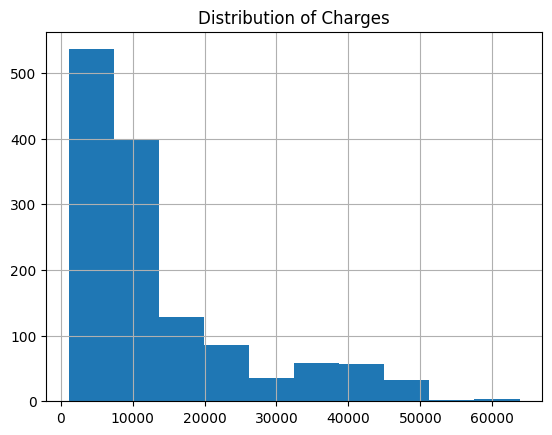

In [3]:

df['charges'].hist()
plt.title('Distribution of Charges')
plt.show()


Observation: Distribution is right-skewed.

## Step 4 — Outliers

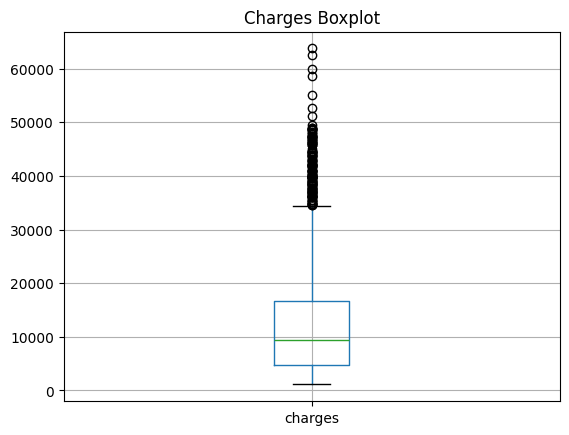

In [4]:

df.boxplot(column='charges')
plt.title('Charges Boxplot')
plt.show()


## Step 5 — Smoker vs Non-Smoker

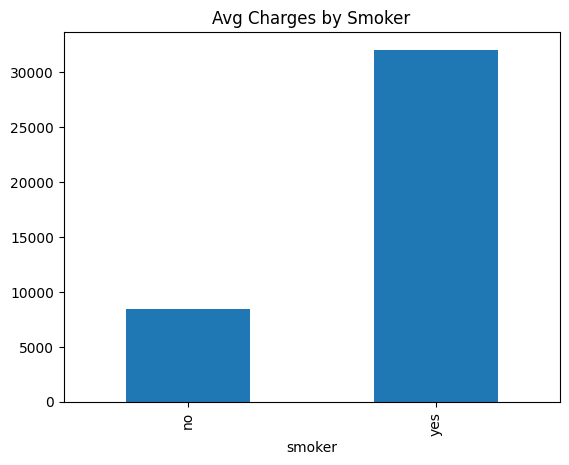

In [5]:

df.groupby('smoker')['charges'].mean().plot(kind='bar')
plt.title('Avg Charges by Smoker')
plt.show()


Insight: Smokers have significantly higher costs.

## Step 6 — SQL with DuckDB

In [6]:

con = duckdb.connect()
con.register('insurance', df)

con.execute("""
SELECT smoker, AVG(charges)
FROM insurance
GROUP BY smoker
""").df()


,smoker,avg(charges)
0,no,8434.268298
1,yes,32050.231832
